File loaded successfully!
Dataset shape: (395, 20)

Model Accuracy: 0.48739495798319327


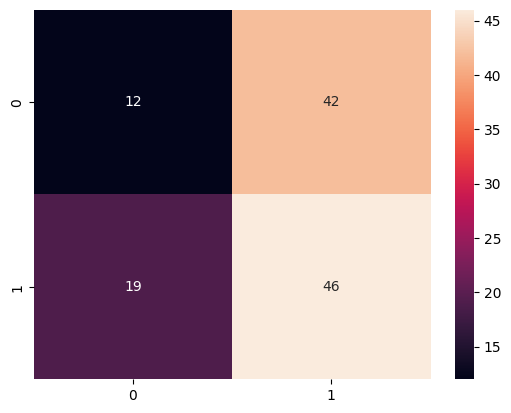

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- FIXING FILE LOADING ---
# The exact name from your screenshot with spaces
file_path = 'student performance.csv'

try:
    # Adding sep=';' because Student datasets often use semicolons
    df = pd.read_csv(file_path, sep=None, engine='python')
    print("File loaded successfully!")
    print(f"Dataset shape: {df.shape}")
except Exception as e:
    print(f"Error: {e}")
    print("Please click the folder icon on the left and ensure the file name is exactly 'student performance.csv'")

# --- REST OF THE CODE ---
if 'df' in locals():
    # 1. Target variable
    df['Pass'] = (df['G3'] >= 10).astype(int)

    # 2. Encoding
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()

    # Selecting only columns that exist in the dataframe
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col] = le.fit_transform(df[col])

    # 3. Feature Engineering
    threshold = df['absences'].median()
    df['high_absenteeism'] = (df['absences'] > threshold).astype(int)
    df['low_study_time'] = (df['studytime'] == 1).astype(int)

    # 4. Modeling
    X = df.drop(['G1', 'G2', 'G3', 'Pass'], axis=1)
    y = df['Pass']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # 5. Output
    y_pred = model.predict(X_test)
    print("\nModel Accuracy:", accuracy_score(y_test, y_pred))

    # Plotting
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
    plt.show()